In [46]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter

In [33]:
files = glob("/data/project/ARM_Summer_School_2026/data/dpscream/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' not in f) and ('5C1' not in f) for f in files]))

ds_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')


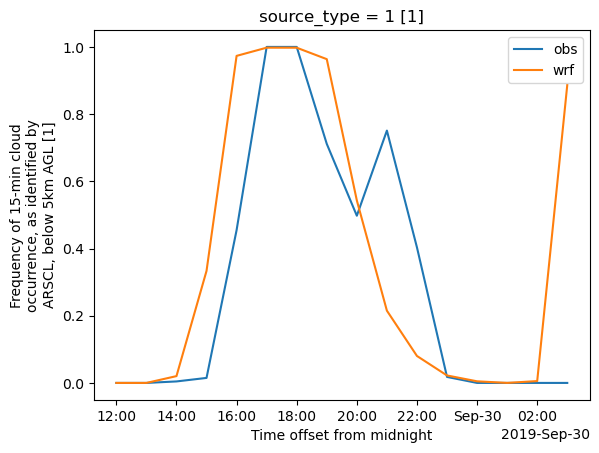

In [52]:
ds_all["time_for_plot"] = ds_all.time.dt.time
ds_all['low_cloud_fraction_arscl'].sel(source_type=0).isel(date = 0).plot(label = "obs")
ds_all['low_cloud_fraction_arscl'].sel(source_type=1).isel(date = 0).plot(label = "wrf")
plt.legend()

In [6]:
ds_dp_scream = xr.open_dataset(
      "/data/project/ARM_Summer_School_2026/data/dpscream/"
      "scream_dpxx_LASSO_SGP_2018-07-09.fullfield.AVERAGE.nhours_x1.2018-07-09-43200.nc"
  )

x = np.unique(ds_dp_scream.lon.values)   # 10 values: 2500, 7500, ..., 47500 m
y = np.unique(ds_dp_scream.lat.values)   # same

cf_colmax = ds_dp_scream['cldfrac_tot'].max(dim='lev')   # (time, ncol)

cf_scream = xr.DataArray(
  cf_colmax.values.reshape(ds_dp_scream.sizes['time'], len(y), len(x)),
  dims=['time', 'y', 'x'],
  coords={
      'time': ds_dp_scream.time,
      'y': y,
      'x': x,
  },
  attrs={'units': '1', 'long_name': 'Column-max total cloud fraction'},
)

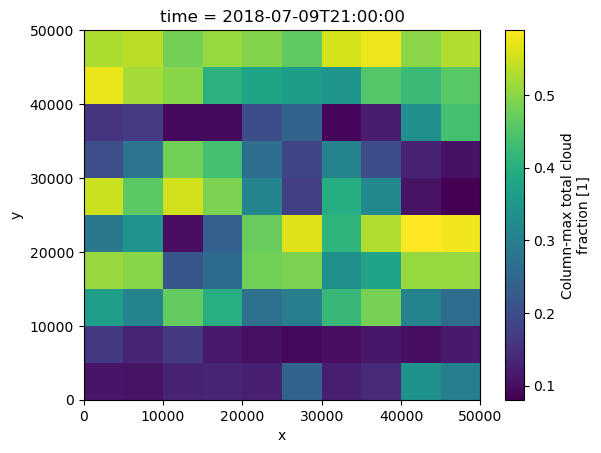

In [7]:
cf_scream.isel(time = 8).plot()